In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('train.csv')

# Sanity checks
print(df.shape)
print(df.dtypes)
df.head()

(80000, 41)
runner_id                          object
age                                 int64
gender                             object
running_experience_months           int64
previous_marathon_count             int64
training_program                   object
motivation_level                    int64
personal_best_minutes             float64
weekly_mileage_km                 float64
weekly_mileage_miles              float64
runs_per_week                       int64
long_run_distance_km              float64
speed_work_sessions_per_week        int64
rest_days_per_week                  int64
training_adherence_pct              int64
consecutive_weeks_no_miss           int64
cross_training_hours_per_week     float64
resting_heart_rate_bpm              int64
vo2_max                           float64
bmi                               float64
recovery_score                    float64
sleep_hours_avg                   float64
injury_count                        int64
injury_severity       

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   runner_id                       80000 non-null  object 
 1   age                             80000 non-null  int64  
 2   gender                          80000 non-null  object 
 3   running_experience_months       80000 non-null  int64  
 4   previous_marathon_count         80000 non-null  int64  
 5   training_program                80000 non-null  object 
 6   motivation_level                80000 non-null  int64  
 7   personal_best_minutes           69255 non-null  float64
 8   weekly_mileage_km               80000 non-null  float64
 9   weekly_mileage_miles            80000 non-null  float64
 10  runs_per_week                   80000 non-null  int64  
 11  long_run_distance_km            80000 non-null  float64
 12  speed_work_sessions_per_week    

runner_id                             0
age                                   0
gender                                0
running_experience_months             0
previous_marathon_count               0
training_program                      0
motivation_level                      0
personal_best_minutes             10745
weekly_mileage_km                     0
weekly_mileage_miles                  0
runs_per_week                         0
long_run_distance_km                  0
speed_work_sessions_per_week          0
rest_days_per_week                    0
training_adherence_pct                0
consecutive_weeks_no_miss             0
cross_training_hours_per_week      7983
resting_heart_rate_bpm                0
vo2_max                            9611
bmi                                   0
recovery_score                        0
sleep_hours_avg                    3942
injury_count                          0
injury_severity                   47350
nutrition_score                    6402


<Axes: xlabel='actual_finish_time_minutes', ylabel='Count'>

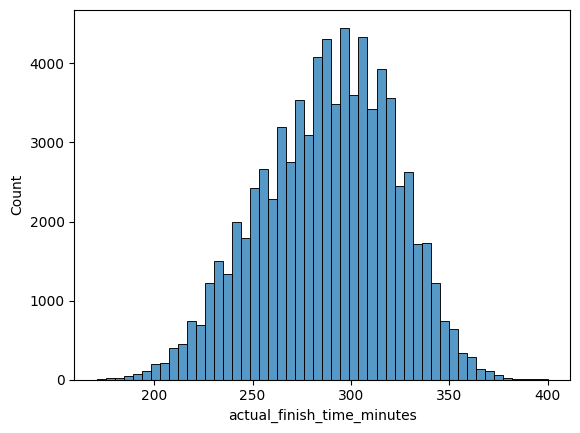

In [4]:
# Target distribution
sns.histplot(df['actual_finish_time_minutes'], bins=50)

In [5]:
df[['target_finish_time_minutes', 'actual_finish_time_minutes']].describe()


,target_finish_time_minutes,actual_finish_time_minutes
count,80000.000000,78011.000000
mean,249.308687,287.931407
std,30.372115,33.648005
min,150.000000,171.000000
25%,228.000000,265.000000
50%,252.000000,290.000000
75%,272.000000,313.000000
max,350.000000,400.000000


In [6]:
# Categorical features
df.select_dtypes(include='object').columns.tolist()

['runner_id',
 'gender',
 'training_program',
 'injury_severity',
 'marathon_date',
 'marathon_weather',
 'course_difficulty']

In [7]:
# 1. Ordinal mappings
training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
course_map = {"Flat": 1, "Mixed": 2, "Hilly": 3}
injury_map = {"Minor": 1, "Moderate": 2, "Severe": 3}

df['training_program'] = df['training_program'].map(training_map)
df['course_difficulty'] = df['course_difficulty'].map(course_map)
df['injury_severity'] = df['injury_severity'].map(injury_map).fillna(0)

# 2. Nominal — one-hot on full df
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe.fit_transform(df[['gender', 'marathon_weather']])
ohe_df = pd.DataFrame(ohe_array,
                      columns=ohe.get_feature_names_out(['gender', 'marathon_weather']),
                      index=df.index)

df = df.drop(columns=['gender', 'marathon_weather'])
df = pd.concat([df, ohe_df], axis=1)

# 3. Filter age group
df_35_44 = df[(df['age'] >= 35) & (df['age'] <= 44)].copy()

# 4. Confirm
print(df_35_44.shape)
print(df_35_44.select_dtypes(include='object').columns.tolist())

(16709, 46)
['runner_id', 'marathon_date']


In [8]:
df_35_44 = df_35_44.drop(columns=['runner_id', 'marathon_date'])

In [9]:
drop_leakage = [
    'personal_best_minutes',
    'target_finish_time_minutes',
    'medal_outcome',
    'weekly_mileage_miles',
    'missed_workout_pct',
    'training_streak_days',
    'dnf'
]

df_35_44 = df_35_44.drop(columns=[c for c in drop_leakage if c in df_35_44.columns])
print(df_35_44.shape)

(16709, 38)


In [10]:
corr_target = df_35_44.corr(numeric_only=True)['actual_finish_time_minutes'].sort_values()
print(corr_target)

training_program                 -0.749693
running_experience_months        -0.657773
speed_work_sessions_per_week     -0.346310
runs_per_week                    -0.313789
vo2_max                          -0.215801
long_run_distance_km             -0.129892
cross_training_hours_per_week    -0.107587
weekly_mileage_km                -0.103680
marathon_weather_Sunny           -0.058755
run_club_attendance_rate         -0.048573
motivation_level                 -0.045955
recovery_score                   -0.036024
goal_completion_rate             -0.034764
weather_condition_training_pct   -0.032684
early_morning_run_frequency      -0.031882
consecutive_weeks_no_miss        -0.030155
warmup_adherence_pct             -0.018629
mental_preparation_score         -0.016351
nutrition_score                  -0.014042
gender_Male                      -0.011881
sleep_hours_avg                  -0.009303
previous_marathon_count          -0.000557
bmi                               0.001209
hydration_c

In [11]:
df_35_44.select_dtypes(include='object').columns.tolist()


[]

In [12]:
print(df_35_44.shape)


(16709, 38)


In [13]:
df_35_44.head()

,age,running_experience_months,previous_marathon_count,training_program,motivation_level,weekly_mileage_km,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,rest_days_per_week,...,course_difficulty,actual_finish_time_minutes,mental_preparation_score,gender_Male,gender_Non-binary,marathon_weather_Cold,marathon_weather_Hot,marathon_weather_Rainy,marathon_weather_Sunny,marathon_weather_Windy
1,43,151,2,3,1,20.0,5,15.0,2,2,...,2,231.0,7,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10,36,83,2,3,4,25.0,6,15.0,2,1,...,2,254.0,6,1.0,0.0,0.0,0.0,1.0,0.0,0.0
15,41,115,1,3,5,20.0,5,15.0,2,2,...,1,274.0,7,1.0,0.0,0.0,0.0,0.0,1.0,0.0
24,42,31,2,2,8,38.7,5,19.3,1,2,...,2,240.0,6,0.0,0.0,1.0,0.0,0.0,0.0,0.0
27,38,6,1,1,5,20.0,3,15.0,1,3,...,2,NaN,10,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [14]:
df_35_44.shape

(16709, 38)

In [15]:
df_35_44.select_dtypes(include='object').columns.tolist()

[]

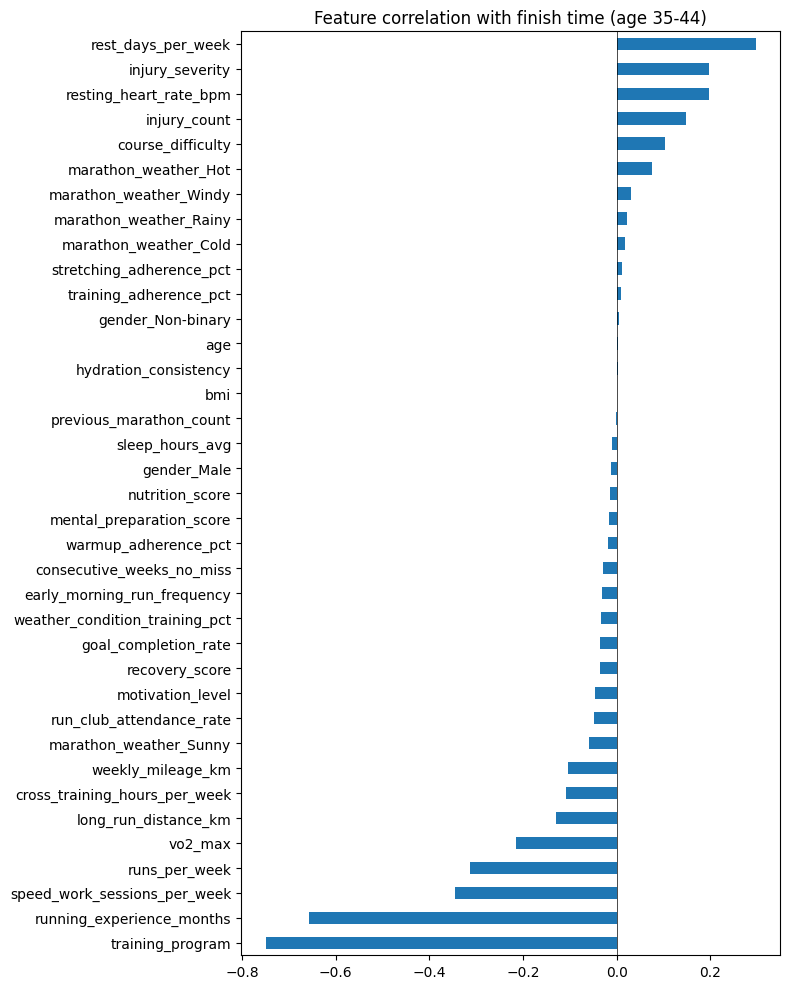

In [16]:
corr_target.drop('actual_finish_time_minutes').plot(kind='barh', figsize=(8, 10))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Feature correlation with finish time (age 35-44)')
plt.tight_layout()

In [17]:
df_35_44.isnull().sum()[df_35_44.isnull().sum() > 0]

cross_training_hours_per_week    1664
vo2_max                          1933
sleep_hours_avg                   803
nutrition_score                  1381
hydration_consistency            1310
actual_finish_time_minutes        406
dtype: int64

In [18]:
X_train = df_35_44.drop(columns=['actual_finish_time_minutes'])
y_train = df_35_44['actual_finish_time_minutes']

In [19]:
[c for c in df_35_44.columns if 'finish' in c.lower() or 'actual' in c.lower()]


['actual_finish_time_minutes']

In [20]:
X_train = X_train.fillna(X_train.median(numeric_only=True))
y_train = y_train.dropna()
X_train = X_train.loc[y_train.index]

In [28]:
model = LinearRegression()
scores = cross_val_score(model, X_train, y_train,
                         cv=5,
                         scoring='neg_mean_absolute_error')

mae = -scores.mean()
print(f"Baseline MAE: {mae:.1f} minutes")

Baseline MAE: 16.1 minutes


/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.inte

In [32]:
scores_r2 = cross_val_score(model, X_train, y_train,
                            cv=5,
                            scoring='r2')

print(f"Baseline R2: {scores_r2.mean():.3f}")

Baseline R2: 0.641


/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.inte